# 1) Chargement des données

### Chargement des librairies

In [1]:
# ============================================================
# ÉTAPE 1 : CHARGEMENT ET CONTRÔLE QUALITÉ
# ============================================================
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Affichage : toutes les colonnes visibles, 3 décimales
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.3f}".format)

# Style graphique commun à tout le notebook
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

print("Librairies chargées.")


Librairies chargées.


### Enregistrement des figures

Je définis ici un petit outil que je réutiliserai à chaque graphique important. Il enregistre
la figure en cours dans un dossier `figures/`, pour que je puisse l'insérer ensuite dans mon
support de présentation.

Trois réglages comptent : `dpi=200` pour que l'image reste nette au vidéoprojecteur,
`bbox_inches="tight"` pour supprimer les marges blanches, et `facecolor="white"` pour éviter
un fond transparent qui deviendrait gris sur une diapositive.

L'appel doit toujours se faire **avant** `plt.show()`, qui vide la figure.

In [2]:
# Dossier de destination des images
DOSSIER_FIG = Path("figures")
DOSSIER_FIG.mkdir(exist_ok=True)


def exporter(nom):
    """Enregistre la figure en cours en PNG. À appeler AVANT plt.show()."""
    plt.savefig(DOSSIER_FIG / f"{nom}.png", dpi=200,
                bbox_inches="tight", facecolor="white")


print("Dossier prêt :", DOSSIER_FIG.resolve())

Dossier prêt : C:\Users\oubak\Desktop\Data analyst\PROJET 12\Livrables\version finale\figures


### Lecture du fichier

In [3]:

DATA_PATH = Path("billets.csv")

# Arrêt immédiat si le fichier est absent avec un message d'erreur
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Fichier introuvable : {DATA_PATH.resolve()}\n"
        "Vérifie que billets.csv est bien à côté de ce notebook."
    )
df = pd.read_csv(DATA_PATH, sep=";")
print(f"Données chargées : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head()

Données chargées : 1500 lignes × 7 colonnes


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.810,104.860,104.950,4.520,2.890,112.830
1,True,171.460,103.360,103.660,3.770,2.990,113.090
2,True,172.690,104.480,103.500,4.400,2.940,113.160
3,True,171.360,103.910,103.940,3.620,3.010,113.510
4,True,171.730,104.280,103.460,4.040,3.480,112.540


### Structure et types de données

In [4]:
# Structure du tableau : lignes, colonnes, types, valeurs renseignées
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


**Constat :**

- **1 500 billets**, **7 colonnes**.
- `is_genuine` est de type `bool` (vrai / faux) : c'est la **variable cible**, ce que mon modèle doit prédire.
- Les 6 autres colonnes sont de type `float64` (nombres à virgule) : ce sont les
  variables explicatives, avec des dimensions géométriques en millimètres comme marqué dans le cahier de charge.
- **`margin_low` n'affiche que 1 463 valeurs** au lieu de 1 500. C'est la seule colonne
  incomplète.

### Comptage des valeurs manquantes

In [5]:
# Nombre et pourcentage des valeurs manquantes par colonne
pd.DataFrame({
    'nb_manquants': df.isna().sum(),
    'pct_manquants':(df.isna().mean() * 100).round(2)
}
)

,nb_manquants,pct_manquants
is_genuine,0,0.000
diagonal,0,0.000
height_left,0,0.000
height_right,0,0.000
margin_low,37,2.470
margin_up,0,0.000
length,0,0.000


**Constat :**
**37 valeurs manquantes, toutes sur `margin_low`**, soit 2,47 % du jeu de données.

### Recherche de doublons
Je fais **deux tests différents**, Un pour les doublons de tout le tableau et l'autre en excluant la colonne is_genuine.

**Test 1 — lignes strictement identiques (7 colonnes).**

In [6]:
# Test 1 : lignes strictement identiques sur les 7 colonnes
df.duplicated().sum()

np.int64(0)

**Test 2 — mesures identiques mais étiquettes opposées.**

In [7]:
# Test 2 : mesures identiques, en ignorant l'étiquette
print(df.drop(columns="is_genuine").duplicated().sum())

0


**Constat : 0 doublon sur les deux tests.** Les 1 500 billets sont tous distincts, RAS pour les doublons

### Équilibre des classes

In [8]:
# Effectifs puis pourcentages de vrais et faux billets
print(df["is_genuine"].value_counts())
print()
print(df["is_genuine"].value_counts(normalize=True) * 100)

is_genuine
True     1000
False     500
Name: count, dtype: int64

is_genuine
True    66.667
False   33.333
Name: proportion, dtype: float64


**Constat : 1 000 vrais (66,7 %) et 500 faux (33,3 %).** Un rapport de 2 pour 1.

## Conclusion de la section 1

| Contrôle | Résultat |
|---|---|
| Volumétrie | 1 500 billets × 7 colonnes |
| Types | 1 booléen (cible) + 6 numériques (mesures en mm) |
| Valeurs manquantes | 37 sur `margin_low` uniquement, soit 2,47 % |
| Doublons | 0, sur les deux tests |
| Équilibre des classes | 1 000 vrais / 500 faux (2:1) |

**Le jeu de données est propre.** Un seul point demande un traitement : les 37 valeurs
manquantes de `margin_low`.

# 2) Analyse exploratoire (EDA)

## Objectif de cette section

L'analyse exploratoire répond à **deux questions** :

1. **Quelles variables faut-il donner au modèle ?**
2. **Le problème est-il facile ou difficile ?**

## 2.1 — Statistiques descriptives

In [9]:
# Liste des 6 variables explicatives (toutes les colonnes sauf la cible)
mesures = [c for c in df.columns if c != "is_genuine"]

In [10]:
# Statistiques descriptives des 6 dimensions.
df.describe()


,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000,1500.000,1500.000,1463.000,1500.000,1500.000
mean,171.958,104.030,103.920,4.486,3.151,112.678
std,0.305,0.299,0.326,0.664,0.232,0.873
min,171.040,103.140,102.820,2.980,2.270,109.490
25%,171.750,103.820,103.710,4.015,2.990,112.030
50%,171.960,104.040,103.920,4.310,3.140,112.960
75%,172.170,104.230,104.150,4.870,3.310,113.340
max,173.010,104.880,104.950,6.900,3.910,114.440


**Ce que je vois :**

Les valeurs sont crédibles. Tout est positif, et les plages restent normales pour des
millimètres : `length` entre 109,49 et 114,44, les hauteurs autour de 104. Pas d'erreur
de saisie évidente.

La ligne `std` montre que les variables ne se dispersent pas pareil. `length` est la plus
étalée (0,873), `margin_up` la moins (0,232), soit presque 4 fois moins. Je devrai donc
mettre les variables à la même échelle avant d'entraîner mes modèles, sinon `length`
comptera plus lourd juste parce qu'elle varie plus.

En comparant `mean` et `50%` (la médiane), je vois que 4 variables sont symétriques : les
deux valeurs sont presque identiques. Mais deux variables penchent d'un côté :

- `margin_low` : moyenne 4,486 contre médiane 4,310. La moyenne est tirée vers le haut.
- `length` : moyenne 112,678 contre médiane 112,960. La moyenne est tirée vers le bas.

Pourquoi ça arrive : la médiane est juste la valeur du milieu du classement, elle ne bouge
pas quand il y a des valeurs extrêmes. La moyenne, elle, additionne tout et se laisse
tirer. Donc si la moyenne dépasse la médiane, il y a des valeurs élevées qui traînent
d'un côté.

Il y a peut-être une explication : mon fichier mélange 1000 vrais et 500 faux billets. Si
les faux avaient une marge basse plus grande et une longueur plus courte, ils formeraient
exactement ce genre de problème. Je vérifie ça en 2.2.

## 2.2 — Distribution des variables

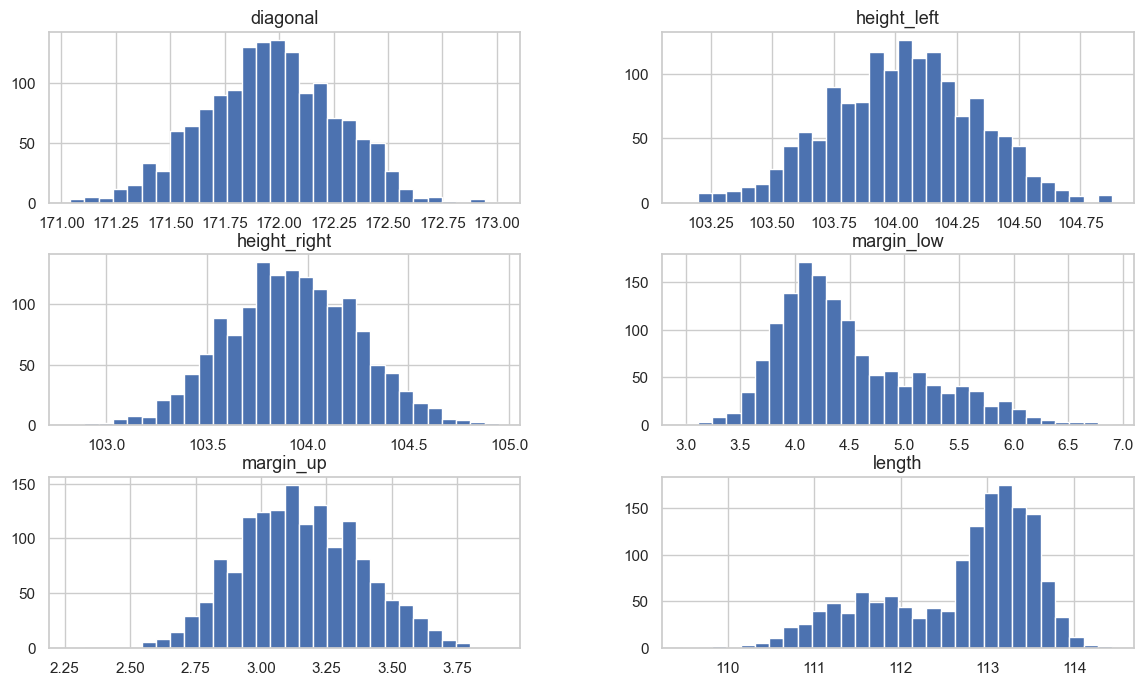

In [11]:
# Forme de la distribution de chacune des 6 variables
df[mesures].hist(bins=30, figsize=(14, 8))
plt.show()

**Constat :**

**`margin_low`et `length` sont les deux variables asymétriques repérées en 2.1.** Ce que la
comparaison moyenne / médiane signalait sous forme de chiffres, l'histogramme le montre
sous forme asymétrique. Les deux approches concordent.

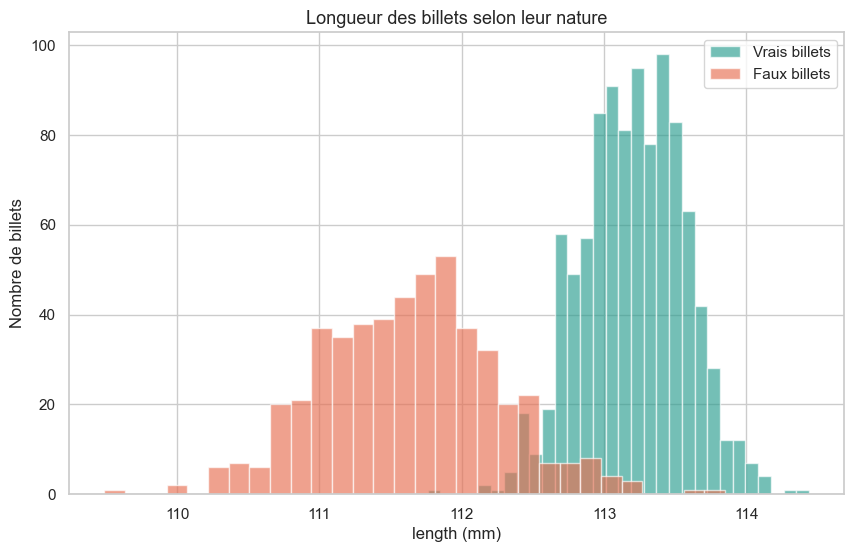

In [12]:
# Distribution de la longueur, séparément pour les vrais et les faux billets
plt.figure(figsize=(10, 6))

# Je fixe les couleurs : vert pour les vrais, orange pour les faux,
# et je garderai ce code couleur dans tout le notebook
plt.hist(df[df["is_genuine"] == True]["length"],
         bins=30, alpha=0.65, color="#2a9d8f", label="Vrais billets")

plt.hist(df[df["is_genuine"] == False]["length"],
         bins=30, alpha=0.65, color="#e76f51", label="Faux billets")

plt.xlabel("length (mm)")
plt.ylabel("Nombre de billets")
plt.title("Longueur des billets selon leur nature")
plt.legend()

exporter("fig_longueur_par_classe")
plt.show()

**Hypothèse confirmée.**

- Les **faux billets** forment le paquet de gauche, centré vers 111,7 mm : ce sont les
  billets **courts**.
- Les **vrais billets** forment le paquet de droite, centré vers 113,2 mm.

L'asymétrie de `length` s'explique donc entièrement : la moyenne (112,678) était inférieure
à la médiane (112,960) parce que les faux billets, plus courts et moins nombreux, tiraient
la moyenne vers le bas sans déplacer la médiane. .

**La zone de recouvrement.** Entre 112,3 et 113 mm environ,
les deux couleurs se mélangent, des faux aussi longs que des vrais, et des vrais aussi
courts que des faux. **C'est là, que le modèle se trompera.** D'après mes recherches et les cours Aucun
algorithme ne peut trancher correctement dans une zone où les deux classes cohabitent.

Conclusion : `length` est une excellente variable, mais elle ne suffira pas seule.
Il faudra en combiner plusieurs pour lever l'ambiguïté dans cette zone.

## 2.3 — Détection des outliers

**Je sépare les vrais et les faux billets.** et je cherche les outliers de chaque groupe

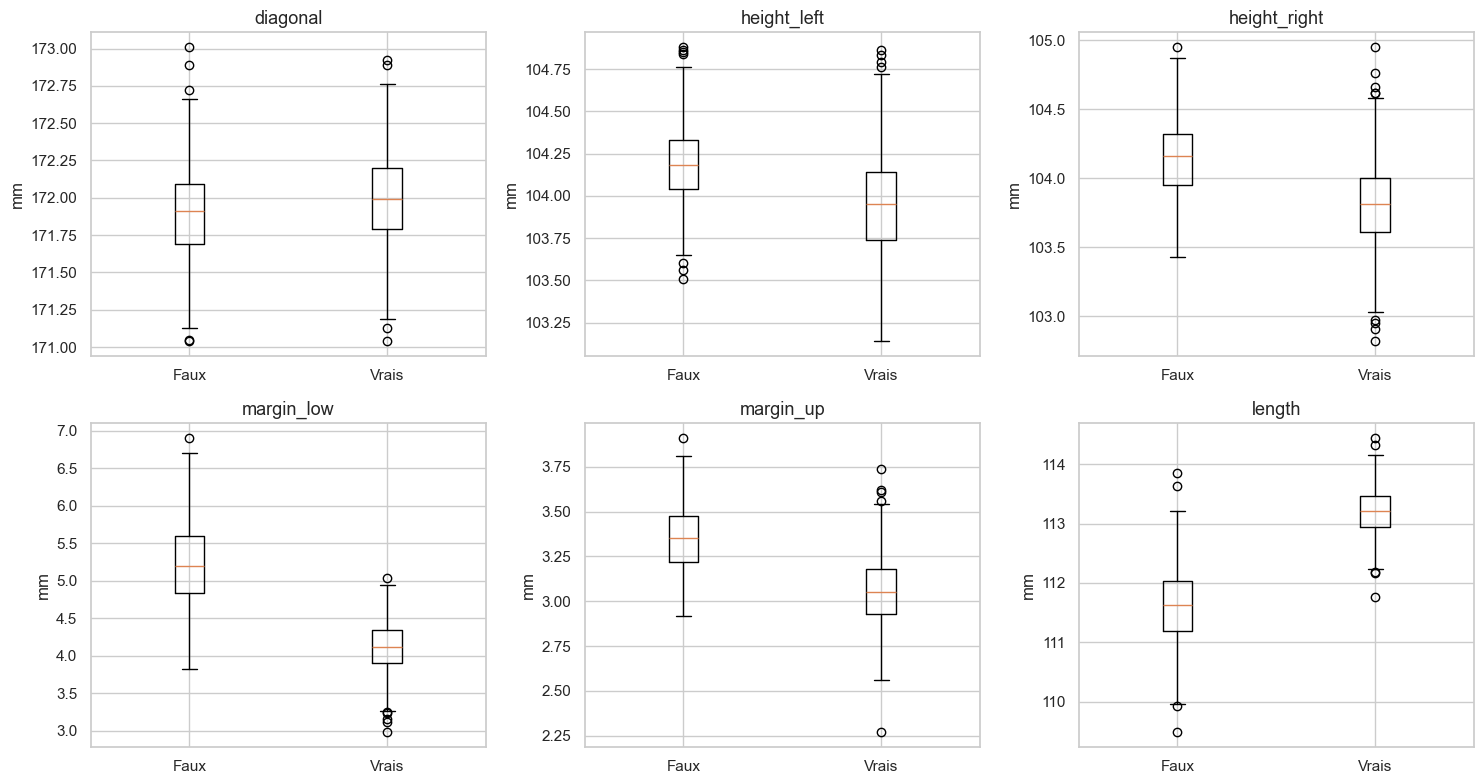

In [13]:
# Boxplot de chaque variable
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, mesures):
    faux = df[~df["is_genuine"]][col].dropna()
    vrais = df[df["is_genuine"]][col].dropna()

    ax.boxplot([faux, vrais])
    ax.set_xticklabels(["Faux", "Vrais"])
    ax.set_title(col)
    ax.set_ylabel("mm")

plt.tight_layout()
exporter("fig_boxplots_par_classe")
plt.show()

In [14]:
# Comptage du nombre de billets atypiques
lignes = []

for nom, sous_groupe in df.groupby("is_genuine"):
    q1 = sous_groupe[mesures].quantile(0.25)
    q3 = sous_groupe[mesures].quantile(0.75)
    iqr = q3 - q1

    # Bornes de Tukey propres à cette classe
    basse = q1 - 1.5 * iqr
    haute = q3 + 1.5 * iqr

    # True si la valeur sort des bornes
    atypique = (sous_groupe[mesures] < basse) | (sous_groupe[mesures] > haute)

    lignes.append(atypique.any(axis=1))

masque = pd.concat(lignes).reindex(df.index)

print("Billets concernés :", masque.sum())
print("Sur 1500, soit", round(masque.mean() * 100, 2), "%")

Billets concernés : 50
Sur 1500, soit 3.33 %


### Conclusion

**50 billets atypiques sur 1500, soit 3,33 %.**

Ce qu'on observe :
- ils sont répartis sur les 6 variables
- presque aucun n'est atypique sur plusieurs variables
- leurs valeurs restent plausibles (millimètres normaux)

**Décision : Je vais les garder.**

Ce ne sont pas des erreurs de mesure, juste des billets un peu hors normes.
Les supprimer serait perdre de l'information vraie.

## 2.4 — Analyse des valeurs manquantes

On a vu déjà qu'on a 37 trous dans `margin_low`, je dois décider qu'est ce que je dois faire avec ces trous
| Option | Principe | Limite |
|---|---|---|
| Supprimer les 37 lignes | Je les retire du jeu de données | Je jette 37 billets réels, donc 37 exemples d'apprentissage |
| Imputer par la moyenne | J'écrits 4,486 dans les 37 trous | Les 37 billets reçoivent une valeur identique alors qu'ils sont tous différents |
| Imputer par régression | J'estime la valeur à partir des 5 autres mesures du même billet | Je suppose que les dimensions sont liées entre elles |

**Je dois savoir si les trous sont répartis au hasard, ou concentrés sur une classe ?** L'enjeu est réel. Si les faux billets avaient beaucoup plus de trous que les vrais, l'absence de mesure serait **elle-même un indice de fausseté**

**Étape 1 — répartition des lignes incomplètes entre les deux classes.**

In [15]:
# À quelle classe appartiennent les 37 billets incomplets ?
df[df["margin_low"].isna()]["is_genuine"].value_counts()

is_genuine
True     29
False     8
Name: count, dtype: int64

Les vrais et les faux ne sont pas en même nombre : 1000 contre 500. Je ne peux donc pas
comparer directement les effectifs bruts. Je calcule un taux au sein de chaque classe,
c'est-à-dire le pourcentage de billets incomplets parmi les vrais, puis parmi les faux.

**Étape 2 — taux de lignes incomplètes au sein de chaque classe.**

In [16]:
# Taux de valeurs manquantes au sein de chaque classe en %
df[df["margin_low"].isna()]["is_genuine"].value_counts()/df["is_genuine"].value_counts() * 100

is_genuine
True    2.900
False   1.600
Name: count, dtype: float64

**Résultat : 2,9 % chez les vrais, 1,6 % chez les faux.**

### Test statistique

Vu le très faible nombre d'observations concernées (8 faux billets
seulement), j'utilise le **test exact de Fisher** qui reste fiable sur petits effectifs,
plutôt qu'un test du khi-deux.

In [17]:

# Test exact de Fisher : les taux de manquants diffèrent-ils entre les deux classes ?
from scipy.stats import fisher_exact

tableau = pd.crosstab(df["margin_low"].isna(), df["is_genuine"]).values.tolist()

odds, p_value = fisher_exact(tableau)
print("p-value =", round(p_value, 4))

p-value = 0.1576


### Conclusion

La p-value est de 0,158. C'est plus grand que 0,05, donc l'écart entre 2,9 % et 1,6 %
peut très bien venir du hasard. Je ne peux pas dire que les valeurs manquantes dépendent
du type de billet.

Ce qui veut dire que je peux remplir ces trous sans perdre d'information.

J'ai choisi de remplacer les 37 valeurs manquantes de `margin_low` en les estimant à
partir des 5 autres mesures du billet, avec une régression linéaire.

Je n'ai pas voulu mettre simplement la moyenne partout, parce que les 37 billets
auraient tous reçu la même valeur alors qu'ils sont tous différents. Avec la régression,
chaque billet reçoit une valeur qui lui correspond.

Je n'utilise pas la colonne `is_genuine` pour cette estimation, pour deux raisons.
D'abord c'est justement ce que mon modèle doit deviner, donc ce serait du triche. Ensuite
cette colonne c'est tout simplement la colonne cible.

Il me reste une chose à vérifier avant d'appliquer : est-ce que les 5 autres mesures
sont vraiment liées à `margin_low` ? Si elles n'ont aucun rapport entre elles, mon
estimation ne vaudrait rien. Je regarde ça juste après, avec les corrélations.

L'imputation elle-même, je la ferai en section 3 avec le reste du prétraitement.

## 2.5 — Les corrélations

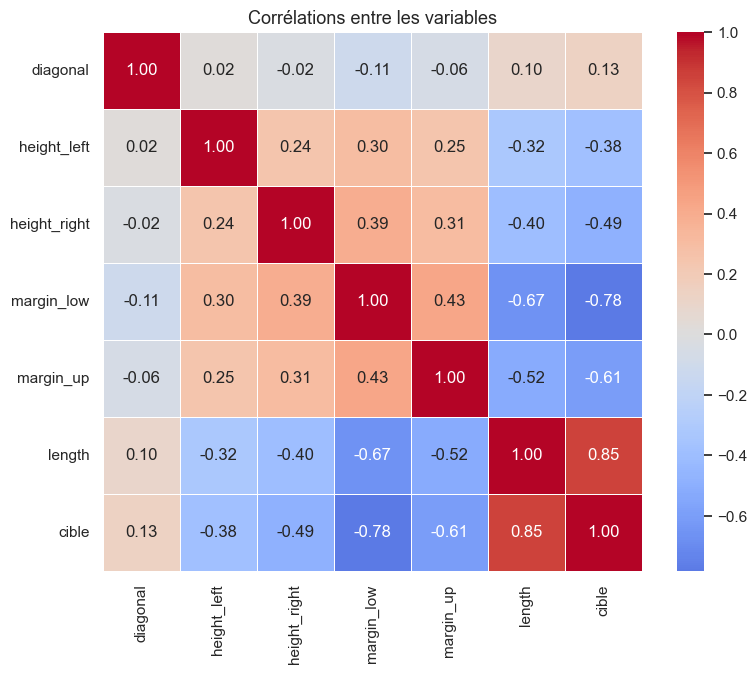

In [18]:
# On ajoute la cible en 0 et 1 pour la faire entrer dans le calcul
df_corr = df[mesures].copy()
df_corr["cible"] = df["is_genuine"].astype(int)

# Calcul des corrélations entre toutes les colonnes
corr = df_corr.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Corrélations entre les variables")

exporter("fig_heatmap_correlations")
plt.show()

## 2.6 — Ce qu'on retient de l'analyse de la deuxième partie

### Les variables

J'ai classé mes 6 variables selon leur lien avec la nature du billet :

| Variable | Corrélation | Lien |
|---|---|---|
| length | +0,85 | très fort |
| margin_low | −0,78 | très fort |
| margin_up | −0,61 | fort |
| height_right | −0,49 | moyen |
| height_left | −0,38 | moyen |
| diagonal | +0,13 | quasi nul |

`length` et `margin_low` sont les deux variables les plus utiles. Ce sont aussi les deux
qui montraient deux cloches dans les histogrammes, et les deux qui penchaient dans le
`describe()`. Les trois approches donnent le même résultat.

**Je garde les 6 variables**, y compris `diagonal`. Je n'en ai que 6 pour 1500 billets,
donc en garder une faible ne gêne pas. Je testerai après l'entraînement si la retirer
change quelque chose.

### Le problème est-il difficile ?

Non. Le graphique de 2.2 montre que les faux billets sont nettement plus courts que les
vrais. Les deux groupes se distinguent bien. Je m'attends donc à de bons scores.

Mais il existe une zone de recouvrement, autour de 112,3 à 113 mm, où des faux sont aussi
longs que des vrais. C'est là que mon modèle se trompera. Aucun algorithme ne peut
trancher quand les deux classes se mélangent. C'est pour ça qu'il faudra combiner
plusieurs variables et pas seulement `length`.

### Ce que j'ai décidé pour la suite

- **Les 50 billets atypiques** : je les garde. Leurs valeurs sont plausibles.
- **Les 37 valeurs manquantes** : je les estime par régression, à partir des 5 autres
  mesures. Le heatmap a confirmé que `margin_low` est bien liée aux autres (−0,67 avec
  `length`), donc l'estimation aura du sens.
- **La standardisation** : obligatoire. `length` se disperse presque 4 fois plus que
  `margin_up`, elle pèserait trop lourd sans mise à l'échelle.
- **La métrique d'évaluation** : je ne me fierai pas au taux de bonnes réponses. Avec 66,7 %
  de vrais billets, un modèle qui répondrait toujours « vrai » aurait 66,7 % de réussite
  sans détecter un seul faux. Or c'est justement les faux qu'il faut trouver.

# 3) Prétraitement

Le but est de transformer tes données brutes (les valeurs mesurées des billets) en données que les algorithmes de Machine Learning peuvent comprendre efficacement.


## 3.1 — Compléter les valeurs manquantes

J'ai 37 billets où `margin_low` n'a pas été mesurée.

Mon idée : les 1463 billets complets vont me servir à apprendre le lien entre `margin_low`
et les 5 autres mesures. Ensuite j'applique ce lien aux 37 billets incomplets pour estimer
leur valeur.

J'utilise une régression linéaire. Elle prédit un nombre, ici une distance en millimètres.

In [19]:
# Les 5 mesures qui vont servir à estimer margin_low
predicteurs = ["diagonal", "height_left", "height_right", "margin_up", "length"]

# Billets complets : ils servent à apprendre
complets = df[df["margin_low"].notna()]

# Billets incomplets : ce sont eux qu'il faut compléter
incomplets = df[df["margin_low"].isna()]

print("Billets complets   :", len(complets))
print("Billets incomplets :", len(incomplets))

Billets complets   : 1463
Billets incomplets : 37


In [20]:
from sklearn.linear_model import LinearRegression

# X = les 5 mesures connues, y = ce qu'on veut apprendre à prédire
X_complets = complets[predicteurs]
y_complets = complets["margin_low"]

# On crée le modèle, puis on lui fait apprendre
modele_imputation = LinearRegression()
modele_imputation.fit(X_complets, y_complets)

print("Modèle entraîné.")

Modèle entraîné.


In [21]:
score = modele_imputation.score(X_complets, y_complets)

print("R² =", round(score, 3))

R² = 0.477


In [22]:
# On applique le modèle aux billets incomplets
X_incomplets = incomplets[predicteurs]
valeurs_estimees = modele_imputation.predict(X_incomplets)

print(valeurs_estimees.round(2))

[4.32 4.39 4.41 4.32 4.65 3.8  4.18 4.13 4.14 4.16 4.18 3.77 4.06 4.3
 4.16 4.09 4.44 4.47 4.34 4.08 3.61 4.37 4.09 4.25 3.89 3.75 4.24 4.71
 4.14 5.05 4.8  5.07 5.05 4.78 5.73 5.19 5.14]


In [23]:
# On garde une copie des données brutes, au cas où
df_original = df.copy()

# On écrit les 37 estimations à leur place
df.loc[df["margin_low"].isna(), "margin_low"] = valeurs_estimees

print("Valeurs manquantes restantes :", df["margin_low"].isna().sum())

Valeurs manquantes restantes : 0


In [24]:
print("Avant :")
print(df_original["margin_low"].describe())
print()
print("Après :")
print(df["margin_low"].describe())

Avant :
count   1463.000
mean       4.486
std        0.664
min        2.980
25%        4.015
50%        4.310
75%        4.870
max        6.900
Name: margin_low, dtype: float64

Après :
count   1500.000
mean       4.483
std        0.660
min        2.980
25%        4.020
50%        4.310
75%        4.870
max        6.900
Name: margin_low, dtype: float64


### Résultat

Mon modèle atteint un R² de 0,477. Il explique donc environ 48 % de `margin_low` à partir
des 5 autres mesures. Ce n'est pas excellent, mais le point de comparaison est la médiane,
qui aurait donné la même valeur à tous les billets. La régression fait mieux, et l'enjeu
reste petit avec 37 valeurs sur 1500.

Les 37 estimations vont de 3,61 à 5,73. Elles sont donc bien différentes les unes des
autres, ce que je cherchais.

Un détail qui me rassure : les 29 vrais billets ont reçu des valeurs entre 3,61 et 4,71,
et les 8 faux entre 4,78 et 5,73. Aucun chevauchement. Le modèle a donné des marges plus
grandes aux faux billets alors que je ne lui ai jamais donné la colonne `is_genuine`. Il
l'a déduit des autres mesures. Ça confirme que mon imputation est cohérente et qu'il n'y
a pas de fuite de données.

Après imputation, la moyenne passe de 4,486 à 4,483 et l'écart-type de 0,664 à 0,660. La
distribution n'a pas été déformée.

`df` ne contient plus aucune valeur manquante.

## 3.2 — Séparer les mesures et la cible

Je coupe mon tableau en deux.

`X` contient les 6 mesures du billet. C'est ce que le modèle va regarder.
`y` contient `is_genuine`. C'est ce qu'il doit deviner.

In [25]:
X = df[mesures]      # Les 6 dimensions géométriques
y = df["is_genuine"] # La cible : vrai ou faux

print("X :", X.shape)
print("y :", y.shape)

X : (1500, 6)
y : (1500,)


## 3.3 — Séparer entraînement et test

Je mets 20 % des billets de côté. Le modèle ne les verra pas pendant son apprentissage.

Pourquoi : si je le notais sur les billets qui lui ont servi à apprendre, il aurait
forcément raison. Sa note ne voudrait rien dire. Il me faut des billets qu'il n'a jamais
vus pour savoir s'il sait vraiment généraliser.

In [26]:
from sklearn.model_selection import train_test_split

# Je mets 20 % des billets de côté pour noter le modèle plus tard
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2,      # 20 % pour le test, 80 % pour l'entraînement
    random_state=42,    # je fige le tirage pour retrouver le même partage à chaque fois
    stratify=y          # je garde le rapport 2 vrais / 1 faux dans les deux paquets
)

print("Entraînement :", X_train.shape[0], "billets")
print("Test         :", X_test.shape[0], "billets")

Entraînement : 1200 billets
Test         : 300 billets


In [27]:
# Vérification que stratify a bien conservé les proportions dans les deux paquets
print("Entraînement :")
print(y_train.value_counts(normalize=True) * 100)
print()
print("Test :")
print(y_test.value_counts(normalize=True) * 100)

Entraînement :
is_genuine
True    66.667
False   33.333
Name: proportion, dtype: float64

Test :
is_genuine
True    66.667
False   33.333
Name: proportion, dtype: float64


Les proportions sont identiques dans les deux paquets : 66,7 % de vrais et 33,3 % de faux,
comme dans le fichier complet. `stratify` a bien fonctionné.

C'était important parce que le partage se fait au hasard. Sans ce paramètre, j'aurais pu
me retrouver avec beaucoup plus de faux billets dans le test que dans l'entraînement, et
ma note aurait été faussée.

## 3.4 — Mettre les variables à la même échelle

Mes 6 variables ne se dispersent pas pareil. `length` a un écart-type de 0,873,
`margin_up` seulement 0,232.

Le problème c'est que le KNN calcule des distances entre billets. Sans standardisation, `length`
compterait beaucoup plus lourd que les autres.

La standardisation a pour but donc de transformer chaque variable pour qu'elle ait une moyenne de 0 et un
écart-type de 1. Toutes les variables vont peser le même poids.

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# J'apprends les moyennes et écarts-types sur l'entraînement
X_train_scaled = scaler.fit_transform(X_train)

# J'applique ces mêmes valeurs au test
X_test_scaled = scaler.transform(X_test)

print("Entraînement :", X_train_scaled.shape)
print("Test         :", X_test_scaled.shape)

Entraînement : (1200, 6)
Test         : (300, 6)


In [29]:
# Après standardisation, chaque variable doit avoir une moyenne de 0 et un écart-type de 1
print("Moyennes :", X_train_scaled.mean(axis=0).round(3))
print("Écarts-types :", X_train_scaled.std(axis=0).round(3))

Moyennes : [ 0. -0.  0. -0.  0. -0.]
Écarts-types : [1. 1. 1. 1. 1. 1.]


### Vérification

Après standardisation, chaque variable a bien une moyenne de 0 et un écart-type de 1.
Les 6 variables pèsent maintenant le même poids.

J'ai utilisé `fit_transform` sur l'entraînement et `transform` sur le test. La différence
est importante : `fit_transform` calcule les moyennes et écarts-types puis transforme,
`transform` réutilise ceux déjà calculés. Si j'avais recalculé sur le test, mon modèle
aurait reçu une information venant du jeu qu'il n'est pas censé connaître.

### Ce dont je dispose pour la suite

- `X_train_scaled` et `y_train` : 1200 billets pour entraîner
- `X_test_scaled` et `y_test` : 300 billets pour noter

# 4) Modélisation

Dans tous domaines, vous ne pouvez pas progresser si vous ne comprenez pas comment vos outils fonctionnent.

Avant d'utiliser les modèles mathématiques qui suivent, je vous recommande donc de visionner les vidéos suivantes:
* [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)
* [StatQuest: K-nearest neighbors, Clearly Explained](https://youtu.be/HVXime0nQeI)
* [StatQuest: Random Forests Part 1 - Building, Using and Evaluating](https://youtu.be/J4Wdy0Wc_xQ)
* [StatQuest: Random Forests Part 2: Missing data and clustering](https://www.youtube.com/watch?v=sQ870aTKqiM)
* [StatQuest: K-means clustering](https://youtu.be/4b5d3muPQmA)

## 4.1 — Régression logistique

C'est un modèle de classification qUi prédit une étiquette et non un nombre.

Le principe : il cherche une séparation entre les vrais et les faux billets. D'un côté les
vrais, de l'autre les faux. Comme j'ai 6 variables, cette frontière n'est pas une simple
droite sur un graphique, mais l'idée reste la même.

Pour chaque billet, il sort une probabilité entre 0 et 1. Proche de 1 le billet est
probablement vrai, proche de 0 il est probablement faux. Au-dessus de 0,5 il tranche pour
« vrai », en dessous pour « faux ».

Ce modèle devrait bien convenir parce que j'ai vu en 2.2 que les deux groupes se séparent
nettement sur `length`.

In [30]:
from sklearn.linear_model import LogisticRegression

# Je crée le modèle
log_reg = LogisticRegression(max_iter=1000)

# Je l'entraîne sur les 1200 billets d'entraînement
log_reg.fit(X_train_scaled, y_train)

print("Modèle entraîné.")

Modèle entraîné.


In [31]:
# Je demande au modèle de deviner le type des 300 billets de test
y_pred_log = log_reg.predict(X_test_scaled)

# Je compare ses réponses avec la vérité
from sklearn.metrics import accuracy_score

print("Bonnes réponses :", round(accuracy_score(y_test, y_pred_log) * 100, 2), "%")

Bonnes réponses : 99.0 %


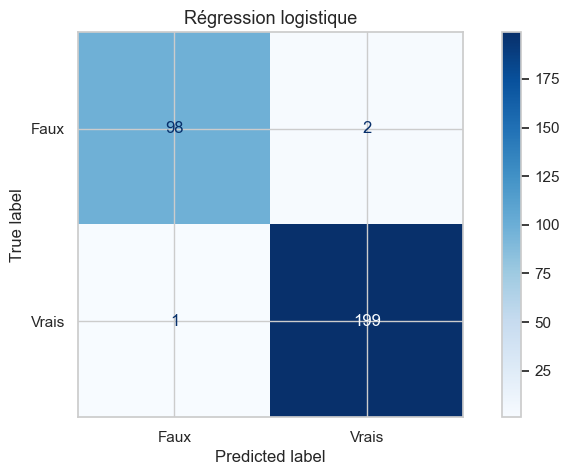

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Je regarde le détail des erreurs
cm = confusion_matrix(y_test, y_pred_log)

ConfusionMatrixDisplay(cm, display_labels=["Faux", "Vrais"]).plot(cmap="Blues")
plt.title("Régression logistique")
plt.show()

In [33]:
from sklearn.metrics import classification_report

# Le détail des métriques pour chaque classe
print(classification_report(y_test, y_pred_log, target_names=["Faux", "Vrais"]))

              precision    recall  f1-score   support

        Faux       0.99      0.98      0.98       100
       Vrais       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [34]:
# La probabilité que le billet soit vrai, selon le modèle
proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

# Je repère les billets où il s'est trompé
erreurs = y_pred_log != y_test.values

print("Probabilités sur ses 3 erreurs :", proba_log[erreurs].round(3))

Probabilités sur ses 3 erreurs : [0.081 0.541 0.686]


### Résultats

Le modèle trouve la bonne réponse dans 99 % des cas sur les 300 billets de test.

La matrice de confusion montre le détail :

| | Il a dit Faux | Il a dit Vrais |
|---|---|---|
| **C'était Faux** | 98 | 2 |
| **C'était Vrais** | 1 | 199 |

Ce qui m'intéresse le plus, c'est le **rappel sur les faux billets : 98 %**. Sur 100 faux
présentés, il en a repéré 98. C'est cette métrique qui correspond à la demande de l'ONCFM,
pas le taux de bonnes réponses.

Il reste 2 faux billets passés pour vrais. Ce sont les erreurs qui coûtent cher, parce que
ces billets entrent dans la circulation. L'erreur inverse, un vrai signalé à tort, est
moins grave : un agent le vérifie à la main.

En regardant les probabilités de ces erreurs (0,081, 0,541 et 0,686), je vois que les deux
erreurs graves correspondent à des hésitations du modèle : 54 % et 69 %, c'est loin d'être
franc. Le seuil de décision est à 0,5 par défaut, mais je peux le déplacer. En exigeant
0,70 pour déclarer un billet vrai, j'attraperais ces deux-là. Je testerai ça après avoir
comparé mes quatre modèles.

### Limite détécté au moment de l'analyse

J'ai imputé `margin_low` sur les 1500 billets, donc avant de séparer l'entraînement et le
test. En toute rigueur, la régression d'imputation aurait dû apprendre uniquement sur les
billets d'entraînement.

Concrètement l'effet est négligeable ici : 37 valeurs sur 1500, et une régression calculée
sur 1463 billets. Les 300 billets de test ne pèsent presque rien dans les coefficients.

Je le note quand même, parce que sur un jeu de données avec beaucoup plus de valeurs
manquantes, cette façon de faire fausserait l'évaluation.

## 4.2 — KNN

Le principe : pour deviner le type d'un billet, je regarde les billets qui lui ressemblent
le plus. Le modèle cherche ses k voisins les plus proches parmi les billets
d'entraînement, puis il fait voter. Si la majorité des voisins sont faux, il répond faux.

proche en distance, calculée sur les 6 mesures. Deux billets aux
dimensions similaires sont voisins.

C'est pour ce modèle que la standardisation était indispensable. Il calcule des distances,
donc sans mise à l'échelle `length` aurait écrasé les autres variables.

Contrairement à la régression logistique, ce modèle ne cherche aucune formule. Il mémorise
tous les billets d'entraînement et compare.

In [35]:
from sklearn.neighbors import KNeighborsClassifier

# Je crée le modèle avec 5 voisins pour commencer
knn = KNeighborsClassifier(n_neighbors=5)

# Je l'entraîne
knn.fit(X_train_scaled, y_train)

# Je lui fais deviner les 300 billets de test
y_pred_knn = knn.predict(X_test_scaled)

print("Bonnes réponses :", round(accuracy_score(y_test, y_pred_knn) * 100, 2), "%")

Bonnes réponses : 98.33 %


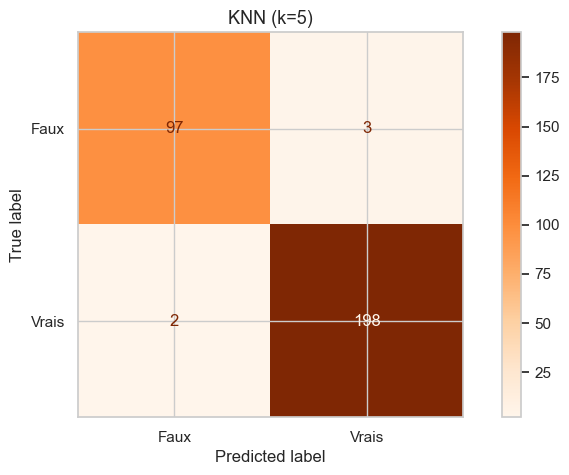

              precision    recall  f1-score   support

        Faux       0.98      0.97      0.97       100
       Vrais       0.99      0.99      0.99       200

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



In [36]:
# Le détail des erreurs du KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)

ConfusionMatrixDisplay(cm_knn, display_labels=["Faux", "Vrais"]).plot(cmap="Oranges")
plt.title("KNN (k=5)")
plt.show()

print(classification_report(y_test, y_pred_knn, target_names=["Faux", "Vrais"]))

In [37]:
# Je teste plusieurs valeurs de k pour trouver la meilleure
from sklearn.metrics import recall_score

for k in [3, 5, 7, 9, 11, 15]:
    modele = KNeighborsClassifier(n_neighbors=k)
    modele.fit(X_train_scaled, y_train)
    pred = modele.predict(X_test_scaled)
    
    # pos_label=False : je veux le rappel sur les FAUX billets
    rappel = recall_score(y_test, pred, pos_label=False)
    
    print(f"k = {k:2d}  →  rappel sur les faux : {rappel:.3f}")

k =  3  →  rappel sur les faux : 0.980
k =  5  →  rappel sur les faux : 0.970
k =  7  →  rappel sur les faux : 0.970
k =  9  →  rappel sur les faux : 0.970
k = 11  →  rappel sur les faux : 0.980
k = 15  →  rappel sur les faux : 0.980


### Choisir k proprement avec la validation croisée

Mon premier test comparait les k sur le jeu de test. C'est un problème : le test doit
rester intact jusqu'à la fin. En m'en servant pour régler un paramètre, je l'utilise deux
fois.

J'utilise donc la validation croisée. Je découpe mes 1200 billets d'entraînement en 5
morceaux. Le modèle apprend sur 4 morceaux et se teste sur le 5ᵉ. Je recommence 5 fois en
changeant le morceau de test, puis je fais la moyenne.

Avantage : mon score repose sur les 1200 billets au lieu de 300, et mon jeu de test reste
intact pour l'évaluation finale.

In [38]:
from sklearn.model_selection import cross_val_score

# Je teste chaque valeur de k avec 5 découpages différents
for k in [3, 5, 7, 9, 11, 15]:
    modele = KNeighborsClassifier(n_neighbors=k)
    
    # cv=5 : cinq découpages. scoring : le rappel sur les faux billets
    scores = cross_val_score(
        modele,
        X_train_scaled, y_train,
        cv=5,
        scoring="recall_macro"
    )
    
    print(f"k = {k:2d}  →  moyenne : {scores.mean():.4f}   écart : {scores.std():.4f}")

k =  3  →  moyenne : 0.9863   écart : 0.0064
k =  5  →  moyenne : 0.9869   écart : 0.0067
k =  7  →  moyenne : 0.9881   écart : 0.0096
k =  9  →  moyenne : 0.9887   écart : 0.0102
k = 11  →  moyenne : 0.9881   écart : 0.0089
k = 15  →  moyenne : 0.9894   écart : 0.0096


### Ce qu'on retient

| k | moyenne | écart-type |
|---|---|---|
| 3 | 0,9863 | 0,0064 |
| 5 | 0,9869 | 0,0067 |
| 7 | 0,9881 | 0,0096 |
| 9 | 0,9887 | 0,0102 |
| 11 | 0,9881 | 0,0089 |
| 15 | 0,9894 | 0,0096 |

L'écart entre le meilleur et le pire k est de 0,0031. Or l'écart-type des scores tourne
autour de 0,009, soit trois fois plus. **Ces différences ne sont donc pas significatives.**
Toutes les valeurs de k testées se valent.

Je ne peux pas choisir sur le score. Je choisis donc sur un principe : plus k est grand,
moins un billet atypique peut faire basculer le vote des voisins. Je retiens **k = 15**,
le plus robuste des six, qui a aussi la meilleure moyenne.

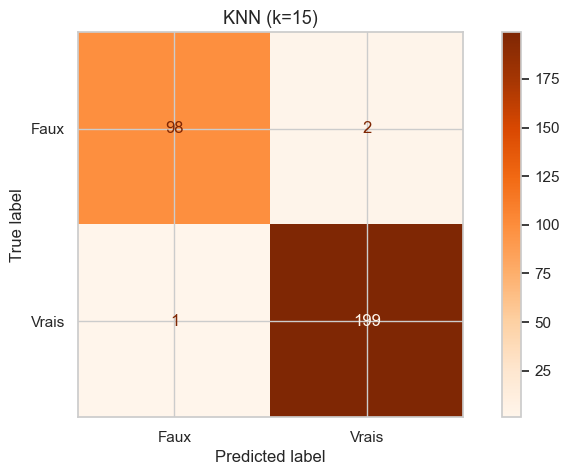

              precision    recall  f1-score   support

        Faux       0.99      0.98      0.98       100
       Vrais       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [39]:
# Mon KNN final, avec le k retenu
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

# Évaluation sur les 300 billets de test, restés intacts
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=["Faux", "Vrais"]).plot(cmap="Oranges")
plt.title("KNN (k=15)")
plt.show()

print(classification_report(y_test, y_pred_knn, target_names=["Faux", "Vrais"]))

### Résultat du KNN final

Avec k=15, j'obtiens exactement la même matrice de confusion que la régression logistique :
98 faux détectés, 2 faux passés, 1 vrai signalé à tort.

Le réglage a servi : avec k=5 je détectais 97 faux et j'avais 2 fausses alertes. En passant
à k=15 je gagne un faux billet et une fausse alerte.

Les deux modèles sont donc à égalité pour l'instant. Je les comparerai avec les deux autres
à la fin.

## 4.3 — Random Forest

Le principe part de l'arbre de décision : une suite de questions du type « la longueur
est-elle inférieure à 112,5 mm ? si oui, la marge basse dépasse-t-elle 4,8 mm ? » jusqu'à
trancher vrai ou faux.

Le problème d'un arbre seul, c'est qu'il apprend par cœur les particularités de ses
données. Il est fragile.

La forêt corrige ça : on construit des centaines d'arbres, chacun sur un échantillon
différent de billets et avec des variables tirées au hasard, puis on les fait voter. Un
arbre seul se trompe, cent arbres qui votent se trompent beaucoup moins.

Deux différences avec mes modèles précédents. D'abord ce modèle n'a pas besoin de
standardisation, parce qu'il compare des seuils au lieu de calculer des distances. Ensuite
il peut me dire quelles variables il utilise le plus, ce qui me permettra de vérifier si
`diagonal` sert vraiment à quelque chose.

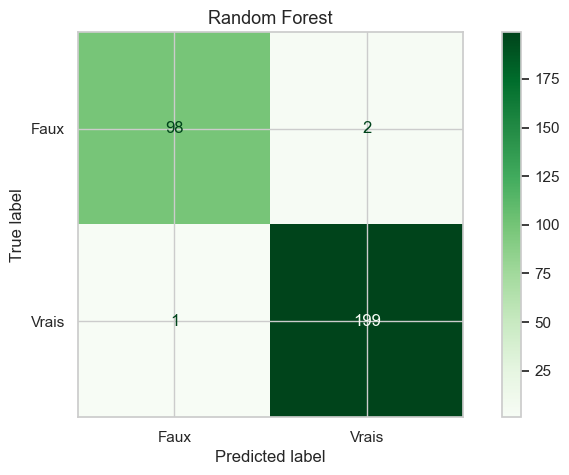

              precision    recall  f1-score   support

        Faux       0.99      0.98      0.98       100
       Vrais       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [40]:
from sklearn.ensemble import RandomForestClassifier

# 200 arbres, et on fige le hasard pour retrouver le même résultat à chaque exécution
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=["Faux", "Vrais"]).plot(cmap="Greens")
plt.title("Random Forest")
plt.show()

print(classification_report(y_test, y_pred_rf, target_names=["Faux", "Vrais"]))

length         0.498
margin_low     0.310
margin_up      0.111
height_right   0.047
height_left    0.026
diagonal       0.008
dtype: float64


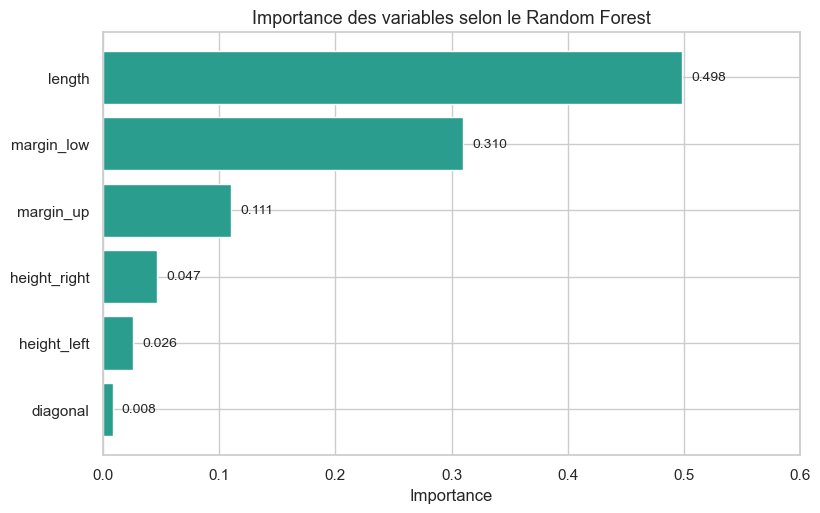

In [41]:
# Le Random Forest me dit quelles variables il a le plus utilisées
importances = pd.Series(rf.feature_importances_, index=mesures)
importances = importances.sort_values(ascending=False)

print(importances.round(3))

plt.figure(figsize=(9, 5.5))
imp = importances.sort_values()   # ordre croissant : la plus utile finit en haut
plt.barh(imp.index, imp.values, color="#2a9d8f")

# J'affiche la valeur au bout de chaque barre
for i, (nom, valeur) in enumerate(imp.items()):
    plt.text(valeur + 0.008, i, f"{valeur:.3f}", va="center", fontsize=10)

plt.xlim(0, 0.6)
plt.xlabel("Importance")
plt.title("Importance des variables selon le Random Forest")

exporter("fig_importances_random_forest")
plt.show()

In [42]:
# Je refais tout sans diagonal, pour voir si ça change quelque chose
mesures_sans_diag = [c for c in mesures if c != "diagonal"]

X_train_sd = X_train[mesures_sans_diag]
X_test_sd = X_test[mesures_sans_diag]

# Nouveau scaler : les colonnes ne sont plus les mêmes
scaler_sd = StandardScaler()
X_train_sd_scaled = scaler_sd.fit_transform(X_train_sd)
X_test_sd_scaled = scaler_sd.transform(X_test_sd)

rf_sd = RandomForestClassifier(n_estimators=200, random_state=42)
rf_sd.fit(X_train_sd_scaled, y_train)
y_pred_sd = rf_sd.predict(X_test_sd_scaled)

print("AVEC diagonal :")
print(confusion_matrix(y_test, y_pred_rf))
print()
print("SANS diagonal :")
print(confusion_matrix(y_test, y_pred_sd))

AVEC diagonal :
[[ 98   2]
 [  1 199]]

SANS diagonal :
[[ 98   2]
 [  1 199]]


### Quelles variables le modèle utilise-t-il ?

| Variable | Importance |
|---|---|
| length | 0,498 |
| margin_low | 0,310 |
| margin_up | 0,111 |
| height_right | 0,047 |
| height_left | 0,026 |
| diagonal | 0,008 |

Ce classement est **exactement le même** que celui des corrélations en 2.5. Deux méthodes
totalement différentes donnent le même ordre. Mon choix de variables ne repose donc pas
sur une impression.

`length` et `margin_low` totalisent 81 % de l'importance. À elles deux, elles font presque
tout le travail.

`diagonal` est à 0,008, soit moins de 1 %. J'ai refait tourner le modèle sans elle : la
matrice de confusion est rigoureusement identique. Elle n'apporte rien.

**Je la garde quand même.** La performance est la même dans les deux cas, donc je choisis
sur un autre critère : les faussaires font évoluer leurs techniques, et une mesure inutile
maintenant peut devenir discriminante après. Comme la machine la mesure de toute façon,
la garder ne coûte rien.

## 4.4 — K-means

Ce modèle est différent des trois autres. Je ne lui donne pas les réponses. Je lui donne
seulement les 6 mesures et je lui demande de ranger les billets en 2 groupes.

C'est de l'apprentissage non supervisé : il cherche une structure sans que je lui dise
quoi chercher.

Comment il marche : il place 2 points au hasard, appelés centroïdes. Ensuite chaque billet
rejoint le centroïde le plus proche, puis chaque centroïde se déplace au centre de son
groupe. Il répète jusqu'à ce que plus rien ne bouge.

Attention : il sort des groupes numérotés 0 et 1. Il ne sait pas lequel correspond aux
vrais billets. C'est à moi de faire le lien après coup.
### Pourquoi ce choix

J'ai choisi le K-means parce que c'est la méthode non supervisée demandée par le cahier
des charges, et parce qu'elle convient à mes données : mes 6 variables sont toutes
numériques et sur une échelle comparable après standardisation, ce qui est exactement le
cas d'usage du K-means.

J'ai fixé le nombre de groupes à 2, parce que je cherche à retrouver les deux catégories
qui m'intéressent : les vrais et les faux billets. Ce n'est donc pas un choix à découvrir,
il est imposé par le problème.

In [43]:
from sklearn.cluster import KMeans

# Je demande 2 groupes. n_init=10 : il essaie 10 départs différents et garde le meilleur
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# Je ne lui donne QUE les mesures, jamais y_train
kmeans.fit(X_train_scaled)

# Le groupe attribué à chaque billet d'entraînement
print("Groupes trouvés :", set(kmeans.labels_))
print("Taille des groupes :", pd.Series(kmeans.labels_).value_counts().to_dict())

Groupes trouvés : {np.int32(0), np.int32(1)}
Taille des groupes : {1: 806, 0: 394}


In [44]:
# Je croise les groupes trouvés avec la vraie réponse
correspondance = pd.crosstab(kmeans.labels_, y_train)

print(correspondance)

is_genuine  False  True 
row_0                   
0             388      6
1              12    794


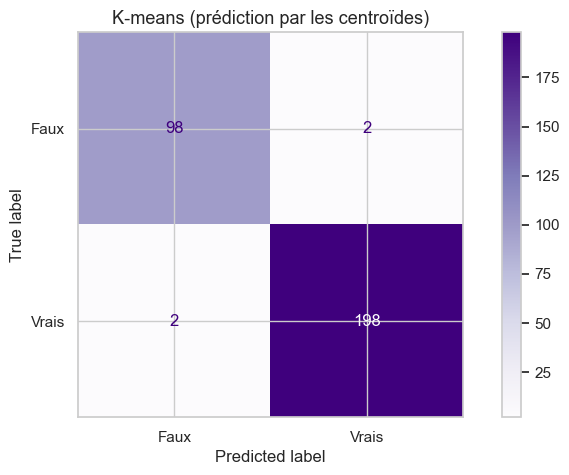

              precision    recall  f1-score   support

        Faux       0.98      0.98      0.98       100
       Vrais       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.99      0.99      0.99       300



In [45]:
# Le lien établi ci-dessus : groupe 0 = faux, groupe 1 = vrais
correspondance_groupes = {0: False, 1: True}

# Pour chaque billet de test, kmeans cherche le centroïde le plus proche
groupes_test = kmeans.predict(X_test_scaled)

# Je traduis les numéros de groupe en vrai/faux
y_pred_kmeans = pd.Series(groupes_test).map(correspondance_groupes)

cm_km = confusion_matrix(y_test, y_pred_kmeans)
ConfusionMatrixDisplay(cm_km, display_labels=["Faux", "Vrais"]).plot(cmap="Purples")
plt.title("K-means (prédiction par les centroïdes)")
plt.show()

print(classification_report(y_test, y_pred_kmeans, target_names=["Faux", "Vrais"]))

### Résultat du K-means

Sur les 1200 billets d'entraînement, il forme deux groupes de 806 et 394 billets. Le vrai
partage est de 800 vrais et 400 faux. Il tombe à 6 billets près, sans avoir jamais vu une
seule réponse.

En croisant ses groupes avec la vérité, le lien est net : le groupe 0 correspond aux faux
(388 faux contre 6 vrais), le groupe 1 aux vrais (794 vrais contre 12 faux).

En utilisant les centroïdes pour prédire les 300 billets de test, j'obtiens 98 faux
détectés sur 100, 2 faux passés et 2 vrais signalés à tort. Une erreur de plus que les
trois autres modèles, et c'est la moins grave des deux.

Ce résultat confirme mon analyse de la section 2 : les vrais et les faux billets sont si
différents sur leurs dimensions qu'ils se séparent d'eux-mêmes, sans supervision.

### La forme des clusters

Je veux savoir si mes deux groupes sont bien formés. Un bon groupe est compact, ses
billets sont serrés, et il est bien séparé de l'autre.

J'utilise le score de silhouette. Pour chaque billet, il compare la distance moyenne à ses
camarades de groupe avec la distance moyenne aux billets de l'autre groupe. Il en sort un
nombre entre −1 et 1.

Proche de 1, le billet est bien à sa place. Proche de 0, il est à la frontière entre les
deux groupes. Négatif, il serait mieux dans l'autre groupe.

In [46]:
from sklearn.metrics import silhouette_score

# Je mesure si les deux groupes sont compacts et bien séparés
score_silhouette = silhouette_score(X_train_scaled, kmeans.labels_)

print("Score de silhouette :", round(score_silhouette, 3))

Score de silhouette : 0.345


### Résultat

Score de silhouette : **0,345**.

Les repères habituels : au-dessus de 0,7 les groupes sont très nettement séparés, entre
0,5 et 0,7 la séparation est bonne, entre 0,25 et 0,5 la structure existe mais reste
modérée, en dessous de 0,25 il n'y a pas de structure claire.

Je suis donc dans la zone modérée. Les deux groupes existent, mais ils ne sont pas très
compacts.

Ça peut sembler contradictoire avec la matrice de confusion, où le K-means détecte 98 faux
sur 100. En fait les deux mesures ne disent pas la même chose. La matrice vérifie si les
groupes correspondent aux vrais et aux faux billets. La silhouette mesure si les groupes
sont compacts et éloignés l'un de l'autre.

L'explication du décalage : j'ai 6 variables, mais seules `length` et `margin_low` séparent
vraiment. Les quatre autres ajoutent du flou, et comme la silhouette calcule des distances
sur les 6 dimensions à la fois, elle en subit l'effet. Un score moyen ne signifie donc pas
que le modèle est mauvais.

### Visualiser les clusters avec une ACP

J'ai 6 dimensions, mais un graphique n'en affiche que 2. L'ACP me permet de compresser :
elle fabrique 2 nouvelles dimensions qui résument au mieux les 6 originales.

L'ACP cherche
la meilleure orientation, celle qui garde le plus de différences entre les billets.

Ces 2 nouvelles dimensions s'appellent F1 et F2. Elles ne correspondent à aucune mesure
réelle, ce sont des mélanges des 6.

In [47]:
from sklearn.decomposition import PCA

# Je compresse mes 6 dimensions en 2
pca = PCA(n_components=2)
coords = pca.fit_transform(X_train_scaled)

# Quelle part de l'information ces 2 dimensions conservent-elles ?
variance = pca.explained_variance_ratio_ * 100

print("F1 :", round(variance[0], 1), "%")
print("F2 :", round(variance[1], 1), "%")
print("Total conservé :", round(variance.sum(), 1), "%")

F1 : 43.3 %
F2 : 17.1 %
Total conservé : 60.4 %


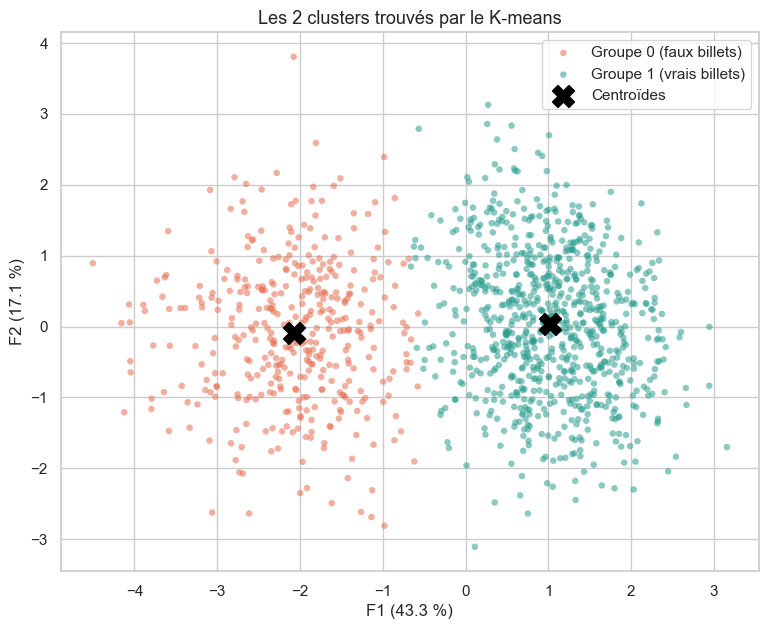

In [48]:
plt.figure(figsize=(9, 7))

# Un point par billet. Je nomme explicitement les deux groupes dans la légende,
# sinon on ne sait pas quelle couleur correspond à quoi
for etiquette, couleur, nom in [(0, "#e76f51", "Groupe 0 (faux billets)"),
                                (1, "#2a9d8f", "Groupe 1 (vrais billets)")]:
    masque_groupe = kmeans.labels_ == etiquette
    plt.scatter(coords[masque_groupe, 0], coords[masque_groupe, 1],
                s=22, alpha=0.55, color=couleur, label=nom, edgecolor="none")

# Je place les 2 centroïdes, projetés dans le même plan
centroides = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroides[:, 0], centroides[:, 1], c="black", marker="X",
            s=250, label="Centroïdes")

plt.xlabel(f"F1 ({variance[0]:.1f} %)")
plt.ylabel(f"F2 ({variance[1]:.1f} %)")
plt.title("Les 2 clusters trouvés par le K-means")
plt.legend()

exporter("fig_acp_clusters")
plt.show()

### Ce qu'on voit

Trois observations.

**La séparation se fait uniquement sur F1.** Les deux groupes sont côte à côte
horizontalement, mais ils occupent la même bande verticale. F2 ne distingue rien.

**Les deux nuages se touchent** vers x = 0. Il n'y a pas d'espace vide entre eux. C'est la
zone de recouvrement que j'avais déjà repérée sur l'histogramme de `length` en 2.2, mais
vue cette fois sur les 6 dimensions à la fois. Ce sont ces billets frontière que mes
modèles se trompent.

**Les nuages sont larges et étalés.** Ils ne forment pas deux boules serrées, les points
s'éparpillent loin de leur centroïde. C'est exactement ce que mesurait le score de
silhouette de 0,345 : des groupes bien présents, mais peu compacts.

Je garde en tête que ces 2 dimensions ne conservent que 60,4 % de l'information. Deux
billets qui paraissent proches sur ce graphique peuvent être plus éloignés en réalité.

### Caractériser les deux groupes

Je sais que mes deux groupes correspondent aux vrais et aux faux billets. Mais je ne sais
pas encore à quoi ils ressemblent concrètement.

F1 et F2 ne veulent rien dire en millimètres, et les données standardisées non plus. Je
reviens donc aux mesures d'origine pour décrire un billet typique de chaque groupe.

In [49]:
# Je repars des mesures réelles, pas des données standardisées
profils = X_train.copy()
profils["groupe"] = kmeans.labels_

# La moyenne de chaque mesure, groupe par groupe
moyennes = profils.groupby("groupe").mean()

print(moyennes.round(2).T)

groupe             0       1
diagonal     171.900 171.990
height_left  104.200 103.950
height_right 104.150 103.810
margin_low     5.220   4.130
margin_up      3.350   3.050
length       111.610 113.180


Le tableau se lit bien, mais un graphique rend l'écart entre les deux groupes beaucoup plus
parlant. Je trace donc la différence de chaque mesure, en millimètres.

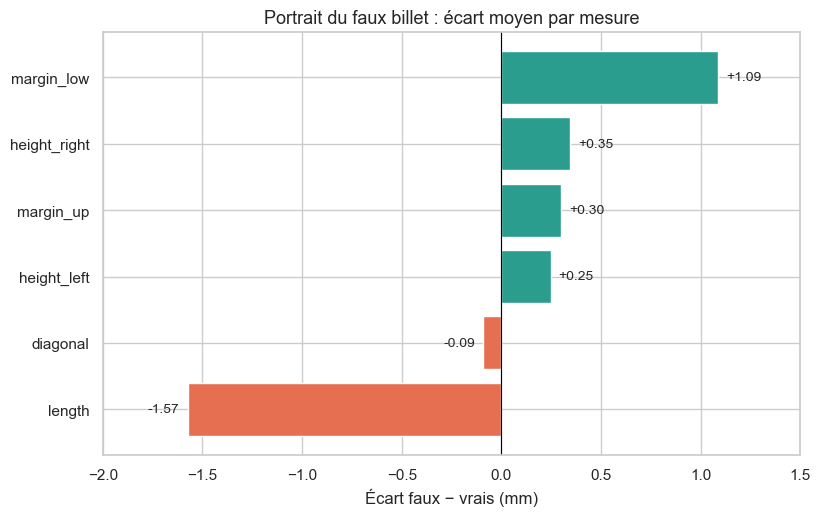

In [50]:
# Écart entre le groupe 0 (faux) et le groupe 1 (vrais), en millimètres
ecarts = (moyennes.loc[0] - moyennes.loc[1]).sort_values()

plt.figure(figsize=(9, 5.5))
couleurs = ["#e76f51" if v < 0 else "#2a9d8f" for v in ecarts]
plt.barh(ecarts.index, ecarts.values, color=couleurs)
plt.axvline(0, color="black", lw=0.8)

# La valeur au bout de chaque barre, du bon côté selon le signe
for i, (nom, valeur) in enumerate(ecarts.items()):
    decalage = 0.04 if valeur >= 0 else -0.04
    plt.text(valeur + decalage, i, f"{valeur:+.2f}", va="center",
             ha="left" if valeur >= 0 else "right", fontsize=10)

plt.xlim(-2, 1.5)
plt.xlabel("Écart faux − vrais (mm)")
plt.title("Portrait du faux billet : écart moyen par mesure")

exporter("fig_portrait_faux_billet")
plt.show()

### Le portrait des deux groupes

| Mesure | Faux (groupe 0) | Vrais (groupe 1) | Écart |
|---|---|---|---|
| length | 111,61 | 113,18 | −1,57 mm |
| margin_low | 5,22 | 4,13 | +1,09 mm |
| height_right | 104,15 | 103,81 | +0,34 mm |
| margin_up | 3,35 | 3,05 | +0,30 mm |
| height_left | 104,20 | 103,95 | +0,25 mm |
| diagonal | 171,90 | 171,99 | −0,09 mm |

**Le faux billet type est plus court de 1,6 mm et sa marge basse est plus grande de
1,1 mm.** Il est aussi très légèrement plus haut, et sa marge du haut un peu plus large.

Sa diagonale, en revanche, est identique à celle d'un vrai : 0,09 mm d'écart, autant dire
rien.

Ça confirme ce que je voyais en 2.5. Les faussaires reproduisent bien la taille globale du
billet. Ce qu'ils ratent, c'est la longueur et le positionnement de l'image sur le papier,
donc les marges.

Une nuance : ces écarts sont en millimètres bruts, donc pas strictement comparables d'une
variable à l'autre puisqu'elles ne se dispersent pas pareil. Mais `length` et `margin_low`
dominent tellement que le classement ne fait aucun doute.

# 5) Choisir le meilleur modèle

## 5.1 — Comparaison des quatre modèles

Je rassemble mes quatre modèles dans un seul tableau pour les comparer sur les mêmes
métriques.

Je regarde quatre choses :

- **Bonnes réponses** : sur les 300 billets, combien de fois le modèle a raison
- **Rappel faux** : sur les 100 faux billets, combien il en attrape. C'est ma métrique
  principale, celle qui répond à la demande de l'ONCFM
- **Précision faux** : quand il dit « faux », à quelle fréquence il a raison
- **F1 faux** : un mélange des deux précédentes, pour avoir un seul chiffre

In [51]:
from sklearn.metrics import precision_score, f1_score

# Je regroupe mes 4 modèles pour les comparer d'un coup
resultats = []

for nom, pred in [
    ("Régression logistique", y_pred_log),
    ("KNN (k=15)", y_pred_knn),
    ("Random Forest", y_pred_rf),
    ("K-means", y_pred_kmeans),
]:
    resultats.append({
        "Modèle": nom,
        "Bonnes réponses": accuracy_score(y_test, pred),
        "Rappel faux": recall_score(y_test, pred, pos_label=False),
        "Précision faux": precision_score(y_test, pred, pos_label=False),
        "F1 faux": f1_score(y_test, pred, pos_label=False),
    })

comparaison = pd.DataFrame(resultats).set_index("Modèle")
print(comparaison.round(3))

                       Bonnes réponses  Rappel faux  Précision faux  F1 faux
Modèle                                                                      
Régression logistique            0.990        0.980           0.990    0.985
KNN (k=15)                       0.990        0.980           0.990    0.985
Random Forest                    0.990        0.980           0.990    0.985
K-means                          0.987        0.980           0.980    0.980


Le tableau montre que les quatre modèles se valent, mais les chiffres seuls ne disent pas
**où** sont les erreurs. Je remets donc les quatre matrices de confusion côte à côte, sur une
seule image : la comparaison devient immédiate.

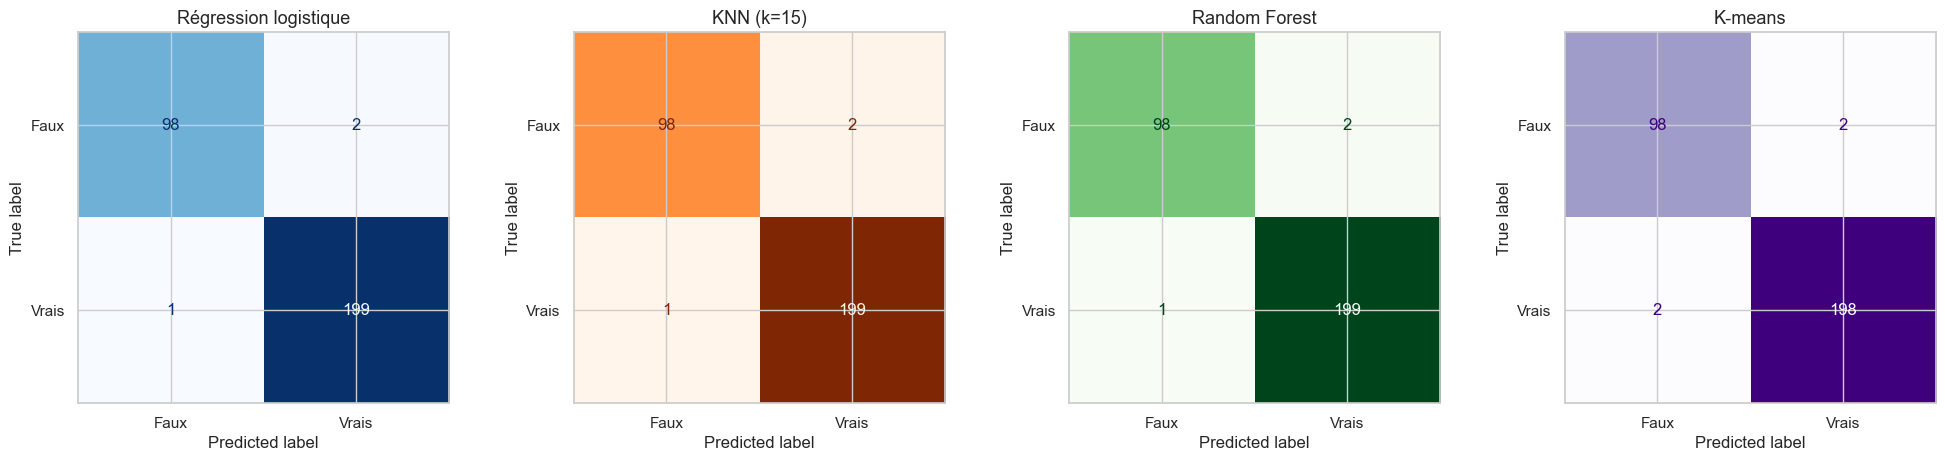

In [52]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))

modeles = [
    ("Régression logistique", y_pred_log,    "Blues"),
    ("KNN (k=15)",            y_pred_knn,    "Oranges"),
    ("Random Forest",         y_pred_rf,     "Greens"),
    ("K-means",               y_pred_kmeans, "Purples"),
]

for ax, (nom, pred, couleur) in zip(axes, modeles):
    cm = confusion_matrix(y_test, pred)
    # colorbar=False : quatre barres de couleur alourdiraient l'image pour rien
    ConfusionMatrixDisplay(cm, display_labels=["Faux", "Vrais"]).plot(
        ax=ax, cmap=couleur, colorbar=False)
    ax.set_title(nom, fontsize=13)

plt.tight_layout()
exporter("fig_matrices_4_modeles")
plt.show()

## 5.2 — Départager avec la validation croisée

Mes trois modèles supervisés donnent exactement les mêmes chiffres. Je ne peux pas choisir
sur ce tableau.

Le problème est le même qu'avec le KNN : ce tableau repose sur un seul découpage de 300
billets. Je refais donc la comparaison en validation croisée sur les 1200 billets
d'entraînement, avec 5 découpages.

Je laisse le K-means de côté ici : il ne se compare pas de la même façon, puisqu'il
n'apprend pas à partir des réponses.

In [53]:
# Je compare mes 3 modèles supervisés sur 5 découpages au lieu d'un seul
modeles = {
    "Régression logistique": LogisticRegression(max_iter=1000),
    "KNN (k=15)": KNeighborsClassifier(n_neighbors=15),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

for nom, modele in modeles.items():
    scores = cross_val_score(modele, X_train_scaled, y_train, cv=5, scoring="recall_macro")
    print(f"{nom:22s} → moyenne : {scores.mean():.4f}   écart : {scores.std():.4f}")

Régression logistique  → moyenne : 0.9869   écart : 0.0094
KNN (k=15)             → moyenne : 0.9894   écart : 0.0096
Random Forest          → moyenne : 0.9856   écart : 0.0102


### Conclusion

| Modèle | Moyenne | Écart-type |
|---|---|---|
| Régression logistique | 0,9869 | 0,0094 |
| KNN (k=15) | 0,9894 | 0,0096 |
| Random Forest | 0,9856 | 0,0102 |

L'écart entre le meilleur et le pire est de 0,0038, alors que l'écart-type tourne autour de
0,010. Le bruit est 2,5 fois plus grand que la différence : **mes trois modèles sont
équivalents**.

Je remarque même que le classement s'est inversé par rapport au jeu de test, où les trois
étaient à égalité parfaite. Ça confirme que ces écarts ne veulent rien dire.

**Je choisis donc sur des critères pratiques, pas sur la performance.**

Je retiens la **régression logistique**, pour trois raisons.

D'abord les probabilités. Ma fiche demande de les utiliser pour confirmer les résultats, et
mon application devra les afficher. La régression logistique sort une probabilité continue,
alors que le KNN avec 15 voisins ne peut produire que 16 valeurs possibles. C'est trop
grossier.

Ensuite j'ai vu que mes deux erreurs graves avaient des probabilités de 0,541 et 0,686. Je
peux donc les rattraper en déplaçant le seuil de décision, mais ça ne fonctionne bien
qu'avec des probabilités fines.

Enfin c'est le modèle le plus simple. Une formule que je peux expliquer, un fichier léger à
sauvegarder, et une prédiction instantanée. Le Random Forest demanderait d'expliquer 200
arbres, et le KNN devrait stocker les 1200 billets d'entraînement pour fonctionner.

## 5.3 — Ajuster le seuil de décision

Mon modèle sort une probabilité entre 0 et 1, et il tranche à 0,5 par défaut. Mais ce 0,5
n'a rien d'obligatoire, c'est simplement la valeur standard.

En montant le seuil, je deviens plus méfiant : il faut une probabilité plus forte pour
qu'un billet soit déclaré vrai. J'attrape donc plus de faux billets, mais je signale aussi
plus de vrais billets à tort.

C'est un arbitrage. Pour l'ONCFM, il penche clairement d'un côté : un faux billet qui entre
en circulation coûte plus cher qu'un vrai billet qu'un agent doit vérifier à la main.

J'avais vu que mes deux erreurs graves avaient des probabilités de 0,541 et 0,686. Un seuil
plus élevé devrait donc les rattraper. Je teste plusieurs valeurs.

In [54]:
# Je teste plusieurs seuils de décision au lieu du 0,5 par défaut
for seuil in [0.5, 0.6, 0.7, 0.8, 0.9]:
    # Le billet est déclaré vrai si sa probabilité dépasse le seuil
    pred = proba_log >= seuil
    
    cm = confusion_matrix(y_test, pred)
    
    print(f"seuil {seuil}  →  faux attrapés : {cm[0, 0]:3d}   "
          f"faux passés : {cm[0, 1]:2d}   fausses alertes : {cm[1, 0]:2d}")

seuil 0.5  →  faux attrapés :  98   faux passés :  2   fausses alertes :  1
seuil 0.6  →  faux attrapés :  99   faux passés :  1   fausses alertes :  1
seuil 0.7  →  faux attrapés : 100   faux passés :  0   fausses alertes :  3
seuil 0.8  →  faux attrapés : 100   faux passés :  0   fausses alertes :  4
seuil 0.9  →  faux attrapés : 100   faux passés :  0   fausses alertes : 11


### Choisir le seuil sans jeu de test

Le problème du balayage précédent : j'ai choisi le seuil en regardant le jeu de test. Le
résultat est donc optimiste, et le test ne sert plus de vraie évaluation.

Je refais le balayage sur mes 1200 billets d'entraînement, en validation croisée. Chaque
billet reçoit une probabilité calculée par un modèle qui ne l'a jamais vu. Mon jeu de test
reste intact pour la vérification finale.

In [55]:
from sklearn.model_selection import cross_val_predict

# Chaque billet reçoit une probabilité calculée par un modèle qui ne l'a pas vu
proba_cv = cross_val_predict(
    LogisticRegression(max_iter=1000),
    X_train_scaled, y_train,
    cv=5,
    method="predict_proba"
)[:, 1]

# Je balaie les seuils sur ces probabilités, pas sur celles du test
for seuil in [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]:
    pred = proba_cv >= seuil
    cm = confusion_matrix(y_train, pred)
    
    print(f"seuil {seuil}  →  faux attrapés : {cm[0, 0]:3d}/400   "
          f"faux passés : {cm[0, 1]:2d}   fausses alertes : {cm[1, 0]:2d}")

seuil 0.5  →  faux attrapés : 391/400   faux passés :  9   fausses alertes :  3
seuil 0.55  →  faux attrapés : 393/400   faux passés :  7   fausses alertes :  4
seuil 0.6  →  faux attrapés : 393/400   faux passés :  7   fausses alertes :  5
seuil 0.65  →  faux attrapés : 393/400   faux passés :  7   fausses alertes :  6
seuil 0.7  →  faux attrapés : 394/400   faux passés :  6   fausses alertes :  7
seuil 0.75  →  faux attrapés : 395/400   faux passés :  5   fausses alertes : 10
seuil 0.8  →  faux attrapés : 395/400   faux passés :  5   fausses alertes : 12
seuil 0.85  →  faux attrapés : 397/400   faux passés :  3   fausses alertes : 16
seuil 0.9  →  faux attrapés : 397/400   faux passés :  3   fausses alertes : 23


In [56]:
# Décision métier : un faux billet qui passe coûte autant que 5 vérifications manuelles
COUT_FAUX_PASSE = 5
COUT_FAUSSE_ALERTE = 1

for seuil in [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]:
    pred = proba_cv >= seuil
    cm = confusion_matrix(y_train, pred)
    
    faux_passes = cm[0, 1]
    fausses_alertes = cm[1, 0]
    cout = COUT_FAUX_PASSE * faux_passes + COUT_FAUSSE_ALERTE * fausses_alertes
    
    print(f"seuil {seuil}  →  coût total : {cout:3d}")

seuil 0.5  →  coût total :  48
seuil 0.55  →  coût total :  39
seuil 0.6  →  coût total :  40
seuil 0.65  →  coût total :  41
seuil 0.7  →  coût total :  37
seuil 0.75  →  coût total :  35
seuil 0.8  →  coût total :  37
seuil 0.85  →  coût total :  31
seuil 0.9  →  coût total :  38


Le coût minimal est atteint à **0,85**. Je retiens donc ce seuil.

Le tableau de chiffres reste difficile à lire d'un coup d'œil. Je trace les deux types
d'erreurs en fonction du seuil : on voit alors clairement l'arbitrage. Quand le seuil monte,
les faux billets non détectés diminuent, mais les fausses alertes augmentent.

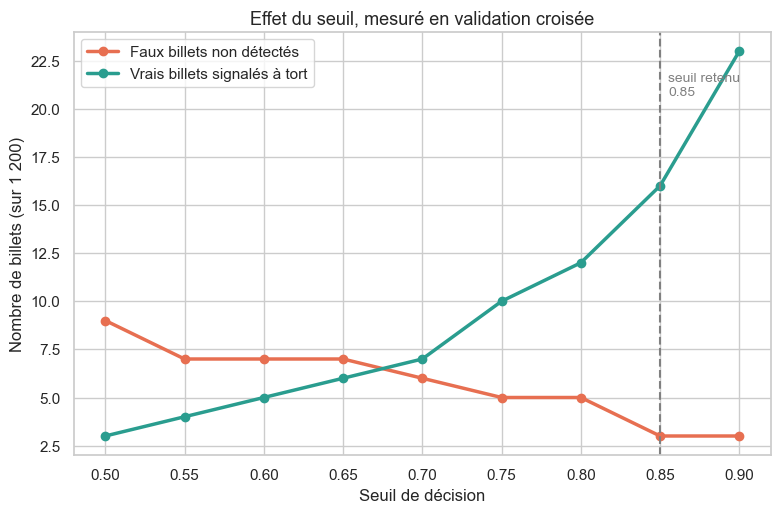

In [57]:
SEUIL = 0.85   # le seuil qui minimise le coût calculé ci-dessus

seuils = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
faux_passes = []
fausses_alertes = []

for s in seuils:
    cm = confusion_matrix(y_train, proba_cv >= s)
    faux_passes.append(cm[0, 1])
    fausses_alertes.append(cm[1, 0])

plt.figure(figsize=(9, 5.5))
plt.plot(seuils, faux_passes, marker="o", lw=2.5, color="#e76f51",
         label="Faux billets non détectés")
plt.plot(seuils, fausses_alertes, marker="o", lw=2.5, color="#2a9d8f",
         label="Vrais billets signalés à tort")

# Je marque le seuil retenu
plt.axvline(SEUIL, ls="--", lw=1.5, color="grey")
plt.text(SEUIL + 0.005, max(fausses_alertes) * 0.9,
         f"seuil retenu\n{SEUIL}", fontsize=10, color="grey")

plt.xlabel("Seuil de décision")
plt.ylabel("Nombre de billets (sur 1 200)")
plt.title("Effet du seuil, mesuré en validation croisée")
plt.legend()

exporter("fig_effet_du_seuil")
plt.show()

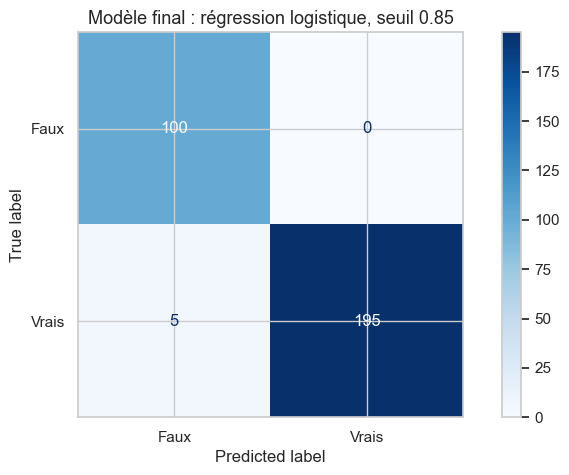

              precision    recall  f1-score   support

        Faux       0.95      1.00      0.98       100
       Vrais       1.00      0.97      0.99       200

    accuracy                           0.98       300
   macro avg       0.98      0.99      0.98       300
weighted avg       0.98      0.98      0.98       300



In [58]:
# SEUIL a été fixé à 0,85 à l'étape précédente
# Je n'utilise le jeu de test que maintenant, une seule fois
y_pred_final = proba_log >= SEUIL

cm_final = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm_final, display_labels=["Faux", "Vrais"]).plot(cmap="Blues")
plt.title(f"Modèle final : régression logistique, seuil {SEUIL}")

exporter("fig_matrice_finale")
plt.show()

print(classification_report(y_test, y_pred_final, target_names=["Faux", "Vrais"]))

### Résultat final

| Seuil | Faux attrapés | Faux passés | Fausses alertes |
|---|---|---|---|
| 0,5 (défaut) | 98 | 2 | 1 |
| **0,85 (retenu)** | **100** | **0** | **5** |

Sur les 300 billets de test, mon modèle final détecte les 100 faux billets, sans en laisser
passer un seul. Il signale 5 vrais billets à tort, qu'un agent devra vérifier à la main.

Par rapport au seuil par défaut, j'ai échangé 4 vérifications manuelles contre 2 faux
billets retirés de la circulation. C'est conforme à ma règle : un faux billet qui passe
vaut 5 vérifications.

**Une réserve importante.** Ce 100 % est un peu chanceux. En validation croisée sur 1200
billets, le même seuil laissait passer environ 3 faux sur 400, soit un rappel de 99,25 %.
Sur seulement 300 billets de test, je tombe à 100 %. La performance réellement attendue sur
de nouveaux billets est donc autour de 99 %, pas de 100 %.

**Sur le choix du seuil.** La courbe des coûts n'est pas régulière : 48, 39, 40, 41, 37,
35, 37, 31, 38. Elle descend, remonte, redescend. Les écarts sont donc en partie du bruit,
et 0,75 était un second choix très proche. J'ai gardé 0,85 parce que ma règle de coût était
fixée avant de voir les résultats. Changer d'avis après coup reviendrait à choisir le seuil
qui m'arrange et à inventer la justification ensuite.

# 6) Sauvegarder le modèle

Mon modèle est choisi et réglé. Il faut maintenant l'enregistrer dans un fichier, pour que
mon application puisse s'en servir sans avoir à refaire tout le notebook.

Mais je ne peux pas sauvegarder seulement la régression logistique. Avant de prédire, mes
données passent par des traitements : compléter les mesures manquantes, puis standardiser.
Si je perds ces étapes, le modèle recevra des données brutes qu'il ne sait pas lire, et il
répondra n'importe quoi.

La solution est le **pipeline** : un seul objet qui contient les traitements et le modèle,
dans le bon ordre. Je le sauvegarde une fois, et il refait toujours les mêmes étapes.

## 6.1 — Construire le pipeline

Mon pipeline aura **3 étapes** :

1. **Compléter les mesures manquantes.** J'ai eu 37 trous dans `margin_low` sur mon fichier
   d'entraînement. Le cas se reproduira sur les fichiers réels, et sans cette étape mon
   application planterait au premier billet incomplet.
2. **Standardiser.** Mettre les 6 variables à la même échelle, comme en 3.4.
3. **Prédire.** La régression logistique retenue en 5.2.

Pour la première étape j'utilise `IterativeImputer` avec une régression linéaire. C'est
exactement ce que j'ai fait à la main en 3.1 : estimer la valeur manquante à partir des
autres mesures du billet.

Un avantage en plus : cette fois l'imputation n'apprend que sur les billets d'entraînement,
puisqu'elle est dans le pipeline. Ça corrige la limite que j'avais signalée en 4.1.

In [59]:
from sklearn.experimental import enable_iterative_imputer  # activation obligatoire
from sklearn.impute import IterativeImputer
from sklearn.pipeline import make_pipeline

# Les 3 étapes, exécutées toujours dans cet ordre
pipeline = make_pipeline(
    IterativeImputer(estimator=LinearRegression(), random_state=42),
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

# Attention : je l'entraîne sur X_train BRUT, pas sur X_train_scaled.
# C'est le pipeline qui se charge d'imputer et de standardiser.
pipeline.fit(X_train, y_train)

print(pipeline)

Pipeline(steps=[('iterativeimputer',
                 IterativeImputer(estimator=LinearRegression(),
                                  random_state=42)),
                ('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])


## 6.2 — Vérifier que le pipeline donne le même résultat

J'ai changé la façon de faire, donc je dois m'assurer que je n'ai pas changé le modèle.
Je compare les prédictions du pipeline avec celles que j'ai validées en 5.3.

Elles doivent être identiques : mon jeu de test ne contient aucune valeur manquante, donc
l'étape d'imputation ne modifie rien.

In [60]:
# Je donne au pipeline les données BRUTES du test
proba_pipeline = pipeline.predict_proba(X_test)[:, 1]
pred_pipeline = proba_pipeline >= SEUIL

print("Résultat identique au modèle validé :", (pred_pipeline == y_pred_final).all())
print()
print(confusion_matrix(y_test, pred_pipeline))

Résultat identique au modèle validé : True

[[100   0]
 [  5 195]]


## 6.3 — Vérifier que le pipeline résiste à un billet incomplet

C'est le vrai test de l'étape d'imputation. Je prends un billet du jeu de test, j'efface
volontairement sa mesure `margin_low`, et je demande une prédiction.

Sans l'imputeur, cette cellule provoquerait une erreur. Avec lui, le pipeline estime la
mesure manquante à partir des 5 autres et sort quand même une probabilité.

In [61]:
# Je fabrique un billet incomplet pour tester la robustesse
billet_incomplet = X_test.head(1).copy()
billet_incomplet.loc[:, "margin_low"] = np.nan

print("Le billet, avec sa mesure effacée :")
print(billet_incomplet)
print()
print("Probabilité obtenue malgré le trou :",
      pipeline.predict_proba(billet_incomplet)[0, 1].round(3))

Le billet, avec sa mesure effacée :
     diagonal  height_left  height_right  margin_low  margin_up  length
803   171.870      103.270       104.500         NaN      3.030 113.190

Probabilité obtenue malgré le trou : 0.996


## 6.4 — Enregistrer le fichier

Je ne sauvegarde pas seulement le pipeline. J'y ajoute deux informations dont mon
application aura besoin :

- **le seuil de 0,85**, choisi en 5.3. Si je ne le sauvegarde pas, mon application
  utilisera le 0,5 par défaut et tout mon travail sur le seuil sera perdu.
- **la liste des 6 colonnes dans le bon ordre**, pour que l'application sache exactement
  quelles mesures fournir et dans quel ordre.

Je range les trois dans un dictionnaire, et j'enregistre le tout avec `joblib`.

In [62]:
import joblib

# Je regroupe le modèle et ses réglages dans un seul objet
modele_complet = {
    "pipeline": pipeline,
    "seuil": SEUIL,
    "colonnes": mesures,
}

joblib.dump(modele_complet, "modele_billets.joblib")

print("Fichier enregistré : modele_billets.joblib")

Fichier enregistré : modele_billets.joblib


In [63]:
# Je recharge le fichier pour vérifier qu'il est bien exploitable
verif = joblib.load("modele_billets.joblib")

print("Seuil rechargé      :", verif["seuil"])
print("Colonnes attendues  :", verif["colonnes"])
print("Test de prédiction  :", verif["pipeline"].predict_proba(X_test.head(2))[:, 1].round(3))

Seuil rechargé      : 0.85
Colonnes attendues  : ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
Test de prédiction  : [0.999 0.   ]


### Ce que contient mon livrable

Le fichier `modele_billets.joblib` contient tout ce qu'il faut pour prédire :

| Élément | Rôle |
|---|---|
| Imputation par régression | Complète une mesure manquante à partir des 5 autres |
| Standardisation | Remet les 6 variables à la même échelle |
| Régression logistique | Sort la probabilité que le billet soit vrai |
| Seuil 0,85 | Transforme cette probabilité en réponse vrai / faux |
| Liste des 6 colonnes | Indique les mesures attendues et leur ordre |

Une précision sur l'entraînement : j'ai entraîné le pipeline sur mes 1 200 billets
d'entraînement, pas sur les 1 500. J'aurais pu tout utiliser, mais alors le modèle livré ne
serait plus celui que j'ai évalué. Là, les résultats de la section 5.3 décrivent exactement
l'objet contenu dans ce fichier.

# 7) Appliquer le modèle au fichier de production

L'ONCFM m'a fourni `billets_production.csv`, qui reproduit le format de ses fichiers
réels. C'est le test final : mon modèle doit être capable de traiter ce fichier tel quel.

Je recharge volontairement le modèle depuis `modele_billets.joblib` au lieu de réutiliser
la variable encore en mémoire. C'est exactement ce que fera mon application, et ça prouve
que mon livrable fonctionne tout seul.

In [64]:
# Je recharge le modèle depuis le fichier, comme le fera l'application
modele = joblib.load("modele_billets.joblib")

pipeline_prod = modele["pipeline"]
seuil_prod = modele["seuil"]
colonnes_prod = modele["colonnes"]

print("Modèle rechargé.")
print("Seuil    :", seuil_prod)
print("Colonnes :", colonnes_prod)

Modèle rechargé.
Seuil    : 0.85
Colonnes : ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']


## 7.1 — Lire le fichier

Attention au séparateur : `billets.csv` utilisait des points-virgules, mais ce fichier-ci
utilise des virgules. Je ne peux pas recopier mon code de la section 1 tel quel.

Ce fichier contient aussi une colonne `id` que je n'avais pas à l'entraînement. Elle
identifie chaque billet mais ce n'est pas une mesure : je ne dois surtout pas la donner
au modèle.

In [65]:
CHEMIN_PROD = Path("billets_production.csv")

if not CHEMIN_PROD.exists():
    raise FileNotFoundError(
        f"Fichier introuvable : {CHEMIN_PROD.resolve()}"
    )

# Séparateur virgule ici, contrairement à billets.csv
prod = pd.read_csv(CHEMIN_PROD)

print(f"{prod.shape[0]} billets à analyser, {prod.shape[1]} colonnes")
prod

5 billets à analyser, 7 colonnes


,diagonal,height_left,height_right,margin_low,margin_up,length,id
0,171.760,104.010,103.540,5.210,3.300,111.420,A_1
1,171.870,104.170,104.130,6.000,3.310,112.090,A_2
2,172.000,104.580,104.290,4.990,3.390,111.570,A_3
3,172.490,104.550,104.340,4.440,3.030,113.200,A_4
4,171.650,103.630,103.560,3.770,3.160,113.330,A_5


In [66]:
# Est-ce que les 6 mesures attendues sont bien présentes ?
manquantes = [c for c in colonnes_prod if c not in prod.columns]

print("Colonnes du fichier   :", list(prod.columns))
print("Colonnes attendues    :", colonnes_prod)
print("Colonnes manquantes   :", manquantes if manquantes else "aucune")
print("Valeurs manquantes    :", prod[colonnes_prod].isna().sum().sum())

Colonnes du fichier   : ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length', 'id']
Colonnes attendues    : ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
Colonnes manquantes   : aucune
Valeurs manquantes    : 0


## 7.2 — Prédire

Je sélectionne les 6 mesures **dans l'ordre enregistré**, en laissant `id` de côté.

Je récupère deux choses : la probabilité que le billet soit vrai, et la réponse
vrai / faux obtenue en comparant cette probabilité à mon seuil de 0,85.

In [67]:
# Les 6 mesures, dans l'ordre attendu par le modèle. La colonne id reste dehors.
X_prod = prod[colonnes_prod]

# Probabilité que le billet soit VRAI
proba_prod = pipeline_prod.predict_proba(X_prod)[:, 1]

# Décision : vrai si la probabilité dépasse le seuil
est_vrai = proba_prod >= seuil_prod

# Je remets tout dans un tableau lisible
resultats_prod = pd.DataFrame({
    "id": prod["id"],
    "probabilite_vrai": proba_prod.round(4),
    "prediction": np.where(est_vrai, "VRAI", "FAUX"),
})

resultats_prod

,id,probabilite_vrai,prediction
0,A_1,0.001,FAUX
1,A_2,0.000,FAUX
2,A_3,0.000,FAUX
3,A_4,0.981,VRAI
4,A_5,1.000,VRAI


### Résultat sur le fichier de production

**3 faux billets (A_1, A_2, A_3) et 2 vrais (A_4, A_5).**

Ces réponses collent au portrait établi en 4.4 : les trois billets déclarés faux sont
courts (111,4 à 112,1 mm) avec une marge basse large (5,0 à 6,0 mm), les deux vrais sont
longs (113,2 et 113,3 mm) avec une marge basse plus fine.

Les probabilités sont toutes collées à 0 ou à 1 : aucun de ces billets n'est un cas
limite. Mon seuil de 0,85 ne change donc rien ici, j'aurais eu les mêmes réponses à 0,5.
Il ne se déclenche que sur les billets ambigus, comme les 2 qu'il avait rattrapés sur mon
jeu de test.

La chaîne complète a fonctionné à partir du fichier

# 8) Démonstration de l'application

Mon algorithme est livré dans un script autonome, `app.py`, comme demandé par le cahier
des charges. Il accepte deux entrées : un chemin vers un fichier CSV, ou la saisie
manuelle des 6 mesures.

Je le lance ici depuis le notebook, exactement comme un utilisateur le ferait depuis un
terminal. Je n'ai pas recopié son code : c'est bien le script livré qui s'exécute.

In [68]:
import sys

# sys.executable = le Python de ce notebook.
# J'appelle explicitement celui-là, sinon Windows lancerait un autre Python
# et le modèle pourrait ne pas se recharger correctement.
!"{sys.executable}" app.py billets_production.csv


RESULTATS  (seuil de decision : 0.85)
id                  proba vrai       verdict
----------------------------------------------
A_1                     0.0011          FAUX
A_2                     0.0002          FAUX
A_3                     0.0004          FAUX
A_4                     0.9809          VRAI
A_5                     0.9998          VRAI
----------------------------------------------
5 billet(s) analyse(s) : 2 vrai(s), 3 faux



### Conclusion

Le script livré traite le fichier de production sans intervention de ma part : il lit le
CSV, complète une éventuelle mesure manquante, standardise, prédit, et applique mon seuil
de 0,85.

Il accepte aussi la saisie manuelle des 6 mesures, comme demandé par le cahier des
charges. Ce mode attend une entrée clavier, que Jupyter gère mal : je le montre en direct
dans le terminal.

Dans les deux cas, la sortie est binaire, accompagnée de la probabilité qui l'a produite.